In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

tf.random.set_seed(42)

# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [ ]:
def build_model():
    model = keras.Sequential([

        layers.Conv2D(32, (3,3), activation='relu', padding='same',kernel_regularizer=regularizers.l1_l2(l1=1e-4, l2=1e-4),input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same' ,kernel_regularizer=regularizers.l1_l2(l1=1e-4, l2=1e-4)),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(128, activation='relu'),

        layers.Dense(10, activation='softmax')
    ])

    return model

In [ ]:
model = build_model()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stop = keras.callbacks.EarlyStopping(
   monitor='val_loss',
   patience=5,              # stop if no improvement for 5 epochs
  restore_best_weights=True
#)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2#,
    callbacks=[early_stop]
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.3598 - loss: 1.8183 - val_accuracy: 0.5705 - val_loss: 1.2887
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5852 - loss: 1.2375 - val_accuracy: 0.6052 - val_loss: 1.1866
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6422 - loss: 1.0790 - val_accuracy: 0.6466 - val_loss: 1.0875
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6801 - loss: 0.9833 - val_accuracy: 0.6606 - val_loss: 1.0463
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7095 - loss: 0.9084 - val_accuracy: 0.6695 - val_loss: 1.0306
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7336 - loss: 0.8444 - val_accuracy: 0.6758 - val_loss: 1.0191
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7520 - loss: 0.7938 - val_accuracy: 0.6729 - val_loss: 1.0445
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7702 - loss: 0.7439 - val_accuracy: 0

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6469 - loss: 2.9350
Test Accuracy: 0.6452999711036682


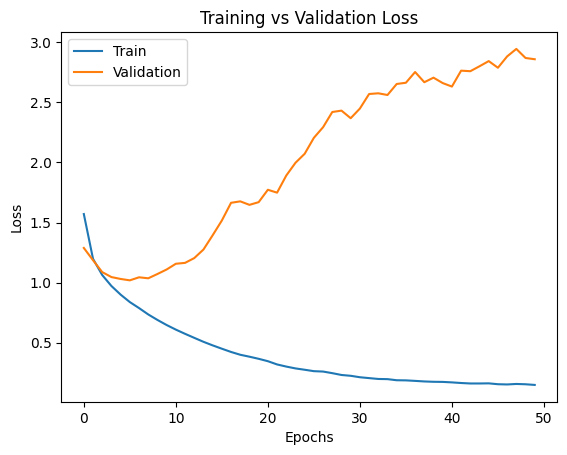

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()